In [138]:
# AVG_TEMP_DATA = os.getcwd() + "\data\CLMTEMP_KP_.csv"
# GSR_DATA = os.getcwd() + "\data\daily_KP_GSR_ALL.csv"
# RH_DATA = os.getcwd() + "\data\daily_KP_RH_ALL.csv"
# SUN_DATA = os.getcwd() + "\data\daily_KP_SUN_ALL.csv"
# RF_DATA = os.getcwd() + "\data\daily_KP_RF_ALL.csv"
# UV_DATA = os.getcwd() + "\data\daily_KP_UV_ALL.csv"
# WSPD_DATA = os.getcwd() + "\data\daily_KP_WSPD_ALL.csv"

import os

parent_dir = os.path.dirname(os.path.dirname(os.getcwd()))
data_dir = os.path.join(parent_dir, "data")
AVG_TEMP_DATA = os.path.join(data_dir, "CLMTEMP_KP_.csv")
GSR_DATA = os.path.join(data_dir, "daily_KP_GSR_ALL.csv")
RH_DATA = os.path.join(data_dir, "daily_KP_RH_ALL.csv")
SUN_DATA = os.path.join(data_dir, "daily_KP_SUN_ALL.csv")
RF_DATA = os.path.join(data_dir, "daily_KP_RF_ALL.csv")
UV_DATA = os.path.join(data_dir, "daily_KP_UV_ALL.csv")
WSPD_DATA = os.path.join(data_dir, "daily_KP_WSPD_ALL.csv") 

print(data_dir)

/home/argonaut/programming/Global-Solar-Radiation-in-King-s-Park/data


In [139]:
# Preprocess data
import pandas as pd
from loguru import logger

try:
    AVG_TEMP_df = pd.read_csv(AVG_TEMP_DATA, parse_dates={'date':['Year', 'Month', 'Day']}, skiprows=[0,1])
    GSR_df = pd.read_csv(GSR_DATA, parse_dates={'date':['Year', 'Month', 'Day']}, skiprows=[0,1])
    RH_df = pd.read_csv(RH_DATA, parse_dates={'date':['Year', 'Month', 'Day']}, skiprows=[0,1])
    SUN_df = pd.read_csv(SUN_DATA, parse_dates={'date':['Year', 'Month', 'Day']}, skiprows=[0,1])
    RF_df = pd.read_csv(RF_DATA, parse_dates={'date':['Year', 'Month', 'Day']}, skiprows=[0,1])
    UV_df = pd.read_csv(UV_DATA, parse_dates={'date':['Year', 'Month', 'Day']}, skiprows=[0,1])
    WSPD_df = pd.read_csv(WSPD_DATA, parse_dates={'date':['Year', 'Month', 'Day']}, skiprows=[0,1])
except:
    logger.error("Error reading data files")
    exit(1)

In [140]:
from utils.DataPreprocessing import DataJoining
join_df = DataJoining(AVG_TEMP_df, GSR_df, RH_df, SUN_df, RF_df, UV_df, WSPD_df)
# logger.info(join_df.info())
# logger.info(join_df.isnull().sum())

# GSR  RH  SUN   RF   UV  WSPD
join_df['GSR'] = pd.to_numeric(join_df['GSR'], errors='coerce')
join_df['RH'] = pd.to_numeric(join_df['RH'], errors='coerce')
join_df['SUN'] = pd.to_numeric(join_df['SUN'], errors='coerce')
join_df['RF'] = pd.to_numeric(join_df['RF'], errors='coerce')
join_df['UV'] = pd.to_numeric(join_df['UV'], errors='coerce')
join_df['WSPD'] = pd.to_numeric(join_df['WSPD'], errors='coerce')

print(join_df)

           Date  AVG_TEMP    GSR  RH  SUN   RF   UV  WSPD
2    1992-07-03      29.6  19.80  79  8.6  0.0  3.0   8.5
3    1992-07-04      29.3   9.19  82  1.4  1.8  3.0  11.0
4    1992-07-05      29.3  14.14  81  1.5  1.0  4.0  14.5
7    1992-07-08      25.2  11.31  83  1.5  0.8  5.0   4.9
8    1992-07-09      27.4  16.08  82  4.2  0.9  2.0   8.9
...         ...       ...    ...  ..  ...  ...  ...   ...
8637 2016-02-28      16.3   2.59  70  0.0  0.4  0.3   4.1
8638 2016-02-29      18.5   6.32  70  0.0  0.0  0.5   9.0
8639 2016-03-01      15.8   6.58  74  0.1  0.0  2.0   6.7
8640 2016-03-02      15.9   7.28  80  0.2  0.0  0.9   3.9
8641 2016-03-03      18.2  15.89  76  5.0  0.0  0.6   4.9

[7739 rows x 8 columns]


In [141]:
from pandas import DataFrame, concat

# transform a time series dataset into a supervised learning dataset
def series_to_supervised(df:DataFrame, time_series_key, n_in=0, n_out=0, dropnan=True):
    temp = df.copy()
    # input sequence (t-n, ... t-1)
    for i in range(n_in, 0, -1):
        # cols.append(df.shift(i))
        # add new column
        # temp['t-'+str(i)] = temp['t'].shift(i)
        temp.insert(0, 't-'+str(i), temp[time_series_key].shift(i))
    # forecast sequence (t, t+1, ... t+n)
    for i in range(1, n_out+1):
        # cols.append(df.shift(-i))
        # add new column
        # temp['t+'+str(i)] = temp['t'].shift(-i)
        temp.insert(0, 't+'+str(i), temp[time_series_key].shift(-i))
    # # put it all together
    # agg = concat(cols, axis=1)
    # drop rows with NaN values
    if dropnan:
        temp.dropna(inplace=True)
    return temp

join_df = series_to_supervised(join_df, "AVG_TEMP", 20, 0)

print(join_df)

       t-1   t-2   t-3   t-4   t-5   t-6   t-7   t-8   t-9  t-10  ...  t-19  \
26    28.0  28.2  28.0  26.7  27.5  27.5  24.8  27.5  28.8  28.5  ...  29.3   
27    28.6  28.0  28.2  28.0  26.7  27.5  27.5  24.8  27.5  28.8  ...  29.3   
28    28.9  28.6  28.0  28.2  28.0  26.7  27.5  27.5  24.8  27.5  ...  25.2   
31    28.5  28.9  28.6  28.0  28.2  28.0  26.7  27.5  27.5  24.8  ...  27.4   
32    29.0  28.5  28.9  28.6  28.0  28.2  28.0  26.7  27.5  27.5  ...  27.5   
...    ...   ...   ...   ...   ...   ...   ...   ...   ...   ...  ...   ...   
8637  15.5  14.9  14.3  13.1  15.4  16.0  14.4  16.1  15.0  13.2  ...  16.8   
8638  16.3  15.5  14.9  14.3  13.1  15.4  16.0  14.4  16.1  15.0  ...  16.5   
8639  18.5  16.3  15.5  14.9  14.3  13.1  15.4  16.0  14.4  16.1  ...  18.8   
8640  15.8  18.5  16.3  15.5  14.9  14.3  13.1  15.4  16.0  14.4  ...  19.2   
8641  15.9  15.8  18.5  16.3  15.5  14.9  14.3  13.1  15.4  16.0  ...  23.1   

      t-20       Date  AVG_TEMP    GSR  RH   SUN   

             t-1   t-2   t-3   t-4   t-5   t-6   t-7   t-8   t-9  t-10  ...  \
Date                                                                    ...   
1992-07-27  28.0  28.2  28.0  26.7  27.5  27.5  24.8  27.5  28.8  28.5  ...   
1992-07-28  28.6  28.0  28.2  28.0  26.7  27.5  27.5  24.8  27.5  28.8  ...   
1992-07-29  28.9  28.6  28.0  28.2  28.0  26.7  27.5  27.5  24.8  27.5  ...   
1992-08-01  28.5  28.9  28.6  28.0  28.2  28.0  26.7  27.5  27.5  24.8  ...   
1992-08-02  29.0  28.5  28.9  28.6  28.0  28.2  28.0  26.7  27.5  27.5  ...   
...          ...   ...   ...   ...   ...   ...   ...   ...   ...   ...  ...   
2016-02-28  15.5  14.9  14.3  13.1  15.4  16.0  14.4  16.1  15.0  13.2  ...   
2016-02-29  16.3  15.5  14.9  14.3  13.1  15.4  16.0  14.4  16.1  15.0  ...   
2016-03-01  18.5  16.3  15.5  14.9  14.3  13.1  15.4  16.0  14.4  16.1  ...   
2016-03-02  15.8  18.5  16.3  15.5  14.9  14.3  13.1  15.4  16.0  14.4  ...   
2016-03-03  15.9  15.8  18.5  16.3  15.5  14.9  14.3

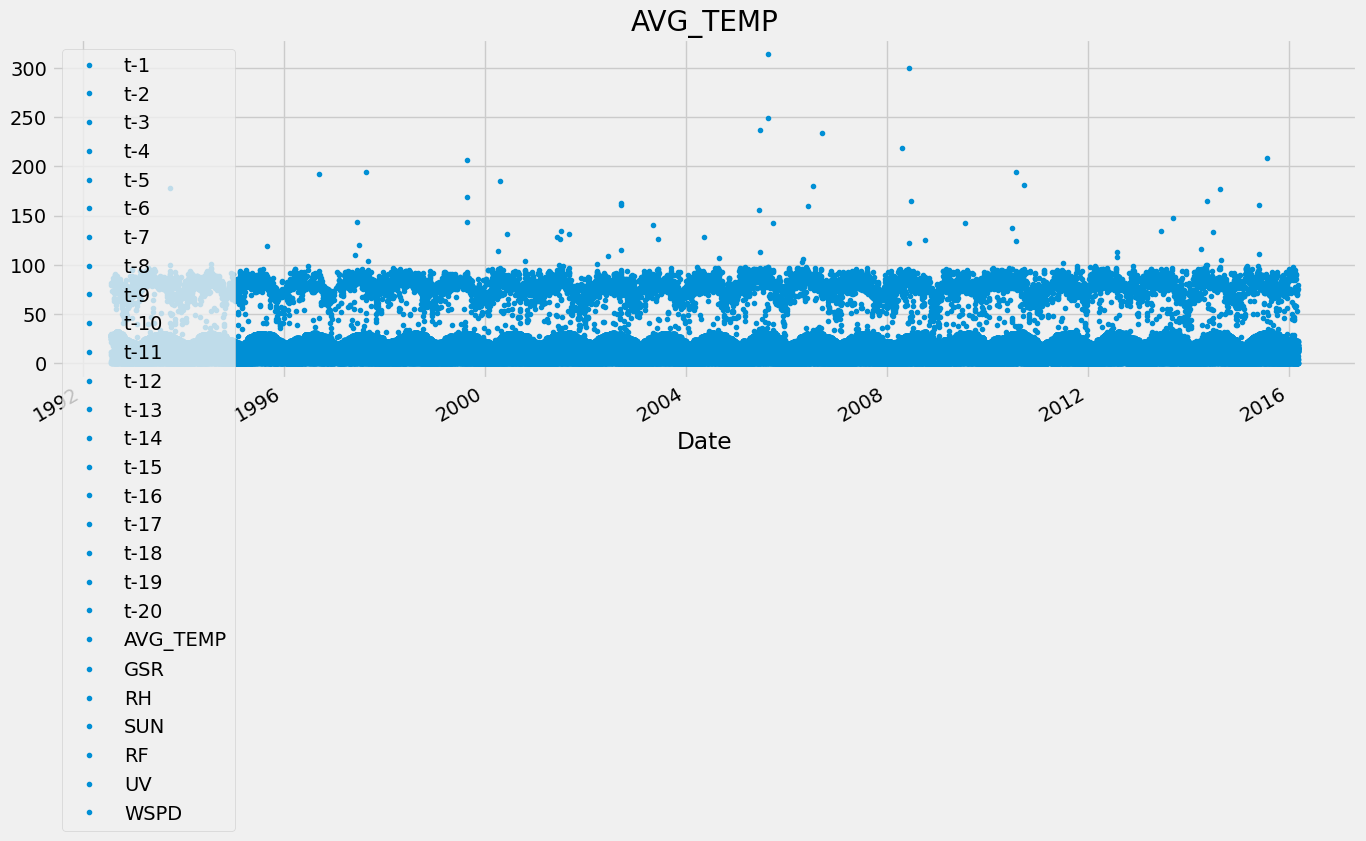

In [142]:
# columns are t-1 ... t-50  Date  AVG_TEMP  GSR  RH  SUN  RF  UV  WSPD
# plot the data with dat in x axis, AVG_TEMP in y axis
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import matplotlib.dates as mdates
# make a function that accept the range of data to plot
import seaborn as sns
color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

def plot_data(df:DataFrame, start=None, end=-1, n=100):
    temp = df.copy()
    temp = temp.set_index('Date')
    temp.index = pd.to_datetime(temp.index)
    print(temp)
    
    cols = temp.columns.tolist()
    cols.remove('AVG_TEMP')
    # temp drop other features except AVG_TEMP
    # temp = temp.drop(columns=cols) # drop other features except AVG_TEMP
    
    # if not start:
    #     start = len(temp) - n
    # if end == -1:
    #     end = len(temp)
        
    # print(start, end)
    # temp = temp[start:end]
    
    temp.plot(style='.',
        figsize=(15, 5),
        color=color_pal[0],
        title='AVG_TEMP')
    
    plt.show()
    return temp

df = plot_data(join_df, n=400)


In [143]:
def create_features(df:DataFrame):
    """
    Create time series features based on time series index.
    """
    
    df = df.copy()
    # df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

print(df)
df = create_features(df)
print(df)

             t-1   t-2   t-3   t-4   t-5   t-6   t-7   t-8   t-9  t-10  ...  \
Date                                                                    ...   
1992-07-27  28.0  28.2  28.0  26.7  27.5  27.5  24.8  27.5  28.8  28.5  ...   
1992-07-28  28.6  28.0  28.2  28.0  26.7  27.5  27.5  24.8  27.5  28.8  ...   
1992-07-29  28.9  28.6  28.0  28.2  28.0  26.7  27.5  27.5  24.8  27.5  ...   
1992-08-01  28.5  28.9  28.6  28.0  28.2  28.0  26.7  27.5  27.5  24.8  ...   
1992-08-02  29.0  28.5  28.9  28.6  28.0  28.2  28.0  26.7  27.5  27.5  ...   
...          ...   ...   ...   ...   ...   ...   ...   ...   ...   ...  ...   
2016-02-28  15.5  14.9  14.3  13.1  15.4  16.0  14.4  16.1  15.0  13.2  ...   
2016-02-29  16.3  15.5  14.9  14.3  13.1  15.4  16.0  14.4  16.1  15.0  ...   
2016-03-01  18.5  16.3  15.5  14.9  14.3  13.1  15.4  16.0  14.4  16.1  ...   
2016-03-02  15.8  18.5  16.3  15.5  14.9  14.3  13.1  15.4  16.0  14.4  ...   
2016-03-03  15.9  15.8  18.5  16.3  15.5  14.9  14.3

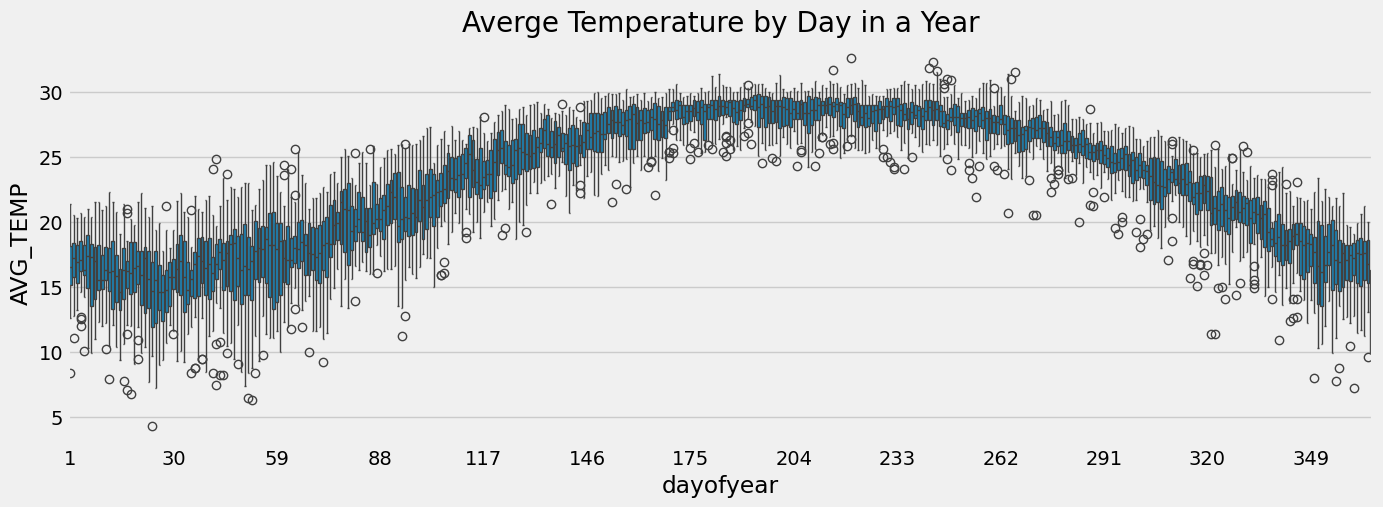

In [144]:
fig, ax = plt.subplots(figsize=(15, 5),)
sns.boxplot(data=df, x='dayofyear', y='AVG_TEMP')
ax.set_title('Averge Temperature by Day in a Year')

# Set the x-axis tick labels
x_ticks = ax.get_xticks()
x_labels = ax.get_xticklabels()
new_x_labels = [label if i % 29 == 0 else '' for i, label in enumerate(x_labels)]
ax.set_xticks(x_ticks)
ax.set_xticklabels(new_x_labels)

plt.show()

In [145]:
print(df)

             t-1   t-2   t-3   t-4   t-5   t-6   t-7   t-8   t-9  t-10  ...  \
Date                                                                    ...   
1992-07-27  28.0  28.2  28.0  26.7  27.5  27.5  24.8  27.5  28.8  28.5  ...   
1992-07-28  28.6  28.0  28.2  28.0  26.7  27.5  27.5  24.8  27.5  28.8  ...   
1992-07-29  28.9  28.6  28.0  28.2  28.0  26.7  27.5  27.5  24.8  27.5  ...   
1992-08-01  28.5  28.9  28.6  28.0  28.2  28.0  26.7  27.5  27.5  24.8  ...   
1992-08-02  29.0  28.5  28.9  28.6  28.0  28.2  28.0  26.7  27.5  27.5  ...   
...          ...   ...   ...   ...   ...   ...   ...   ...   ...   ...  ...   
2016-02-28  15.5  14.9  14.3  13.1  15.4  16.0  14.4  16.1  15.0  13.2  ...   
2016-02-29  16.3  15.5  14.9  14.3  13.1  15.4  16.0  14.4  16.1  15.0  ...   
2016-03-01  18.5  16.3  15.5  14.9  14.3  13.1  15.4  16.0  14.4  16.1  ...   
2016-03-02  15.8  18.5  16.3  15.5  14.9  14.3  13.1  15.4  16.0  14.4  ...   
2016-03-03  15.9  15.8  18.5  16.3  15.5  14.9  14.3

In [146]:
from sklearn.model_selection import train_test_split

x_df = df.drop(columns=['AVG_TEMP'])
y_df = df['AVG_TEMP']

x_train, x_test, y_train, y_test = train_test_split(x_df, y_df, test_size=0.3, random_state=0)

In [147]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

reg = xgb.XGBRegressor(base_score=0.5, booster='gbtree',    
                #        n_estimators=1000,
                       early_stopping_rounds=50,
                       objective='reg:linear',
                #        max_depth=3,
                #        learning_rate=0.01
                       )

# set up our search grid
param_grid = {"max_depth": range(3, 7, 1),
              "n_estimators": range(500, 1000, 100),
              "learning_rate": [0.01, 0.015]}

search = GridSearchCV(reg, param_grid, cv=5, verbose=1).fit(x_train, y_train)

print("The best hyperparameters are ",search.best_params_)

reg:xgb.XGBRegressor=xgb.XGBRegressor(learning_rate = search.best_params_["learning_rate"],
                                   n_estimators = search.best_params_["n_estimators"],
                                   max_depth = search.best_params_["max_depth"],
                                   early_stopping_rounds=50,
                                   objective='reg:linear',
                                   base_score=0.5, 
                                   booster='gbtree',)

reg.fit(x_train, y_train,
        eval_set=[(x_train, y_train), (x_test, y_test)],
        verbose=100)

[0]	validation_0-rmse:22.88492	validation_1-rmse:23.02765
[100]	validation_0-rmse:8.52003	validation_1-rmse:8.59007


/home/argonaut/programming/Global-Solar-Radiation-in-King-s-Park/venv/lib/python3.11/site-packages/xgboost/core.py:160: UserWarning: [00:12:23] WARNING: /workspace/src/objective/regression_obj.cu:209: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)


[200]	validation_0-rmse:3.40501	validation_1-rmse:3.45624
[300]	validation_0-rmse:1.77609	validation_1-rmse:1.83660
[400]	validation_0-rmse:1.37832	validation_1-rmse:1.45413
[500]	validation_0-rmse:1.28427	validation_1-rmse:1.37126
[600]	validation_0-rmse:1.24983	validation_1-rmse:1.34558
[700]	validation_0-rmse:1.22801	validation_1-rmse:1.33233
[800]	validation_0-rmse:1.20850	validation_1-rmse:1.32211
[900]	validation_0-rmse:1.19093	validation_1-rmse:1.31391
[999]	validation_0-rmse:1.17584	validation_1-rmse:1.30788


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=None,
             num_parallel_tree=None, objective='reg:linear', ...)

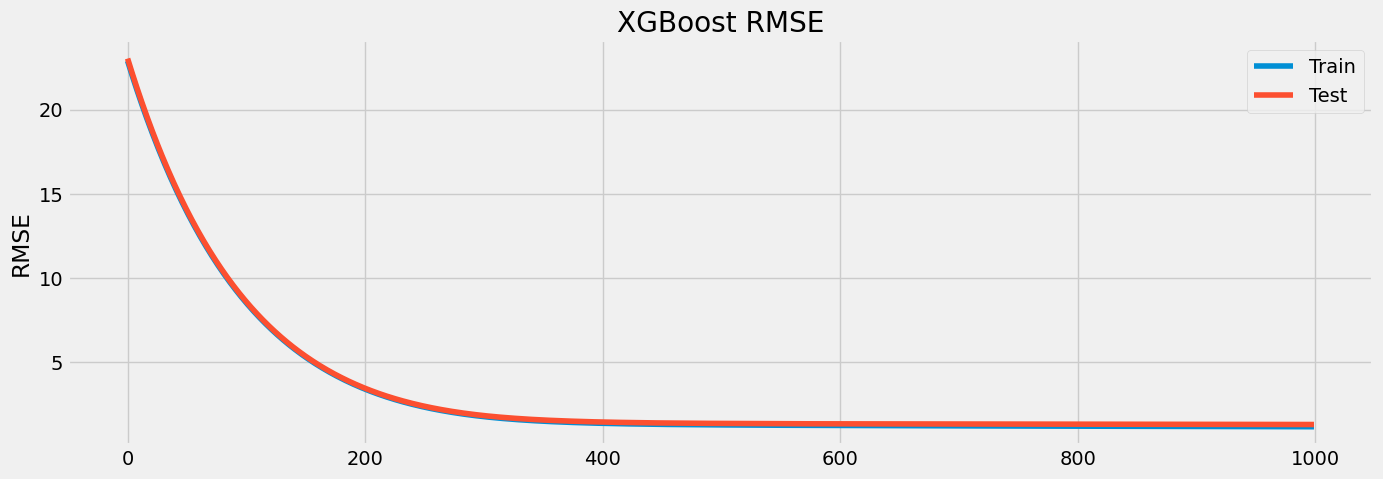

In [148]:
# plot the loss
results = reg.evals_result()
epochs = len(results['validation_0']['rmse'])
x_axis = range(0, epochs)
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(x_axis, results['validation_0']['rmse'], label='Train')
ax.plot(x_axis, results['validation_1']['rmse'], label='Test')
ax.legend()
plt.ylabel('RMSE')
plt.title('XGBoost RMSE')
plt.show()

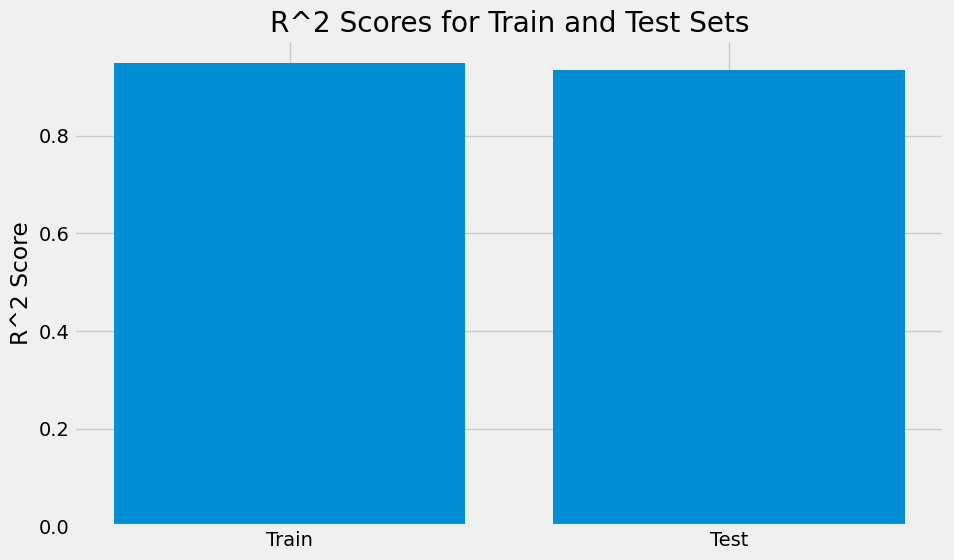

R^2 score for train set:  0.9484047656785672
R^2 score for test set:  0.9352200054664934


In [149]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Predict the values
y_train_pred = reg.predict(x_train)
y_test_pred = reg.predict(x_test)

# Calculate R^2 scores
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

# Plot R^2 scores
plt.figure(figsize=(10, 6))
plt.bar(['Train', 'Test'], [r2_train, r2_test])
plt.title('R^2 Scores for Train and Test Sets')
plt.ylabel('R^2 Score')
plt.show()

print("R^2 score for train set: ", r2_train)
print("R^2 score for test set: ", r2_test)

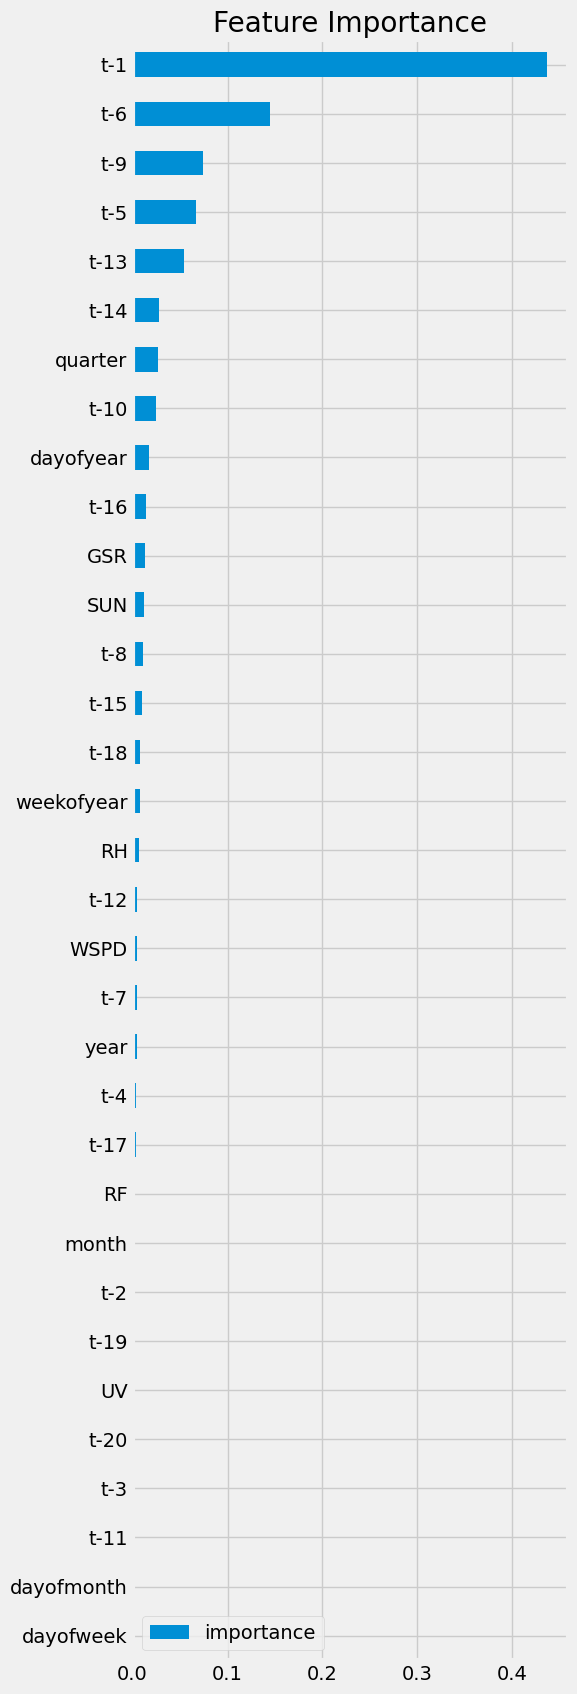

In [150]:
fi = pd.DataFrame(data=reg.feature_importances_,
             index=reg.feature_names_in_,
             columns=['importance'])
fi.sort_values('importance').plot(kind='barh', title='Feature Importance', figsize=(5, 20))
plt.show()

In [151]:
from utils.DataPreprocessing import DataPreprocessing

x_train, x_test, y_train, y_test = DataPreprocessing(join_df) # 7:3

print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)
print(x_train)

correlation matrix: 
               t-1       t-2       t-3       t-4       t-5       t-6  \
t-1       1.000000  0.951446  0.895659  0.862766  0.843303  0.832226   
t-2       0.951446  1.000000  0.951440  0.895662  0.862747  0.843278   
t-3       0.895659  0.951440  1.000000  0.951449  0.895648  0.862725   
t-4       0.862766  0.895662  0.951449  1.000000  0.951455  0.895657   
t-5       0.843303  0.862747  0.895648  0.951455  1.000000  0.951449   
t-6       0.832226  0.843278  0.862725  0.895657  0.951449  1.000000   
t-7       0.825856  0.832164  0.843219  0.862724  0.895621  0.951421   
t-8       0.821114  0.825826  0.832134  0.843236  0.862705  0.895600   
t-9       0.816773  0.821092  0.825802  0.832164  0.843221  0.862680   
t-10      0.811366  0.816749  0.821067  0.825802  0.832140  0.843193   
t-11      0.805946  0.811344  0.816726  0.821063  0.825779  0.832114   
t-12      0.801596  0.805914  0.811311  0.816737  0.821037  0.825743   
t-13      0.797047  0.801565  0.805883  0.8

In [152]:

regressor = xgb.XGBRegressor(eval_metric='rmse')

from sklearn.model_selection import GridSearchCV
# set up our search grid
param_grid = {"max_depth":    [4, 5, 6],
              "n_estimators": [500, 600, 700],
              "learning_rate": [0.01, 0.015]}

# search = GridSearchCV(regressor, param_grid, cv=5, verbose=1).fit(x_train, y_train)

# print("The best hyperparameters are ",search.best_params_)

In [153]:
# regressor:xgb.XGBRegressor=xgb.XGBRegressor(learning_rate = search.best_params_["learning_rate"],
#                            n_estimators  = search.best_params_["n_estimators"],
#                            max_depth     = search.best_params_["max_depth"],
#                            eval_metric='rmsle')

# regressor.fit(x_train, y_train)

# predictions = regressor.predict(x_test)

# import numpy as np
# from sklearn.metrics import mean_squared_error
# RMSLE = mean_squared_error(y_test, predictions)
# print("The score is %.5f" % RMSLE )